# 00 — Fit Distribution Parameters

Loads IEEE-CIS, PaySim, and ULB datasets, fits real statistical parameters
(amount distribution, timing, MCC frequency, fraud ratio), and writes them
to `config/distribution_params.yaml`. This is the ONLY place real data is
used directly — everything downstream generates its own synthetic data
using these fitted parameters.

**Run order: this notebook first, before 01_identify_and_generate.ipynb.**

In [1]:
# --- Setup: clone repo / mount Drive, install deps ---
# Option A: clone from GitHub (replace with your repo URL once pushed)
# !git clone https://github.com/YOUR_ORG/fraud-redteam-project.git
# %cd fraud-redteam-project

# Option B: mount Drive if you're syncing the folder there instead
# from google.colab import drive
# drive.mount('/content/drive')
# %cd /content/drive/MyDrive/fraud-redteam-project

from google.colab import drive
drive.mount('/content/drive')

import sys
# Add the project to the Python path so modules can be imported
sys.path.append('/content/drive/MyDrive/Closed-Loop/fraud-redteam-project_final')

import os
# Change the working directory to the project folder
os.chdir('/content/drive/MyDrive/Closed-Loop/fraud-redteam-project_final')

!pip install -q pandas numpy scipy pyyaml matplotlib kaggle

Mounted at /content/drive


## Step 1 — Download the datasets

See `README.md` Section 1 for full instructions. Quick version:

In [4]:
from google.colab import files
files.upload() # upload kaggle.json from kaggle.com/settings -> Create New API Token

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!mkdir -p data/raw_reference/ieee_cis data/raw_reference/paysim data/raw_reference/ulb

# NOTE: IEEE-CIS is a competition dataset - you must click "Join Competition" once at
# https://www.kaggle.com/c/ieee-fraud-detection before this download will succeed.
!kaggle competitions download -c ieee-fraud-detection -p data/raw_reference/ieee_cis
!kaggle datasets download -d ealaxi/paysim1 -p data/raw_reference/paysim
!kaggle datasets download -d mlg-ulb/creditcardfraud -p data/raw_reference/ulb

!cd data/raw_reference/ieee_cis && unzip -oq '*.zip'
!cd data/raw_reference/paysim && unzip -oq '*.zip'
!cd data/raw_reference/ulb && unzip -oq '*.zip'
!ls data/raw_reference/ieee_cis data/raw_reference/paysim data/raw_reference/ulb


Saving kaggle.json to kaggle.json
100% 118M/118M [00:00<00:00, 172MB/s]

Dataset URL: https://www.kaggle.com/datasets/ealaxi/paysim1
License(s): CC-BY-SA-4.0
100% 178M/178M [00:01<00:00, 94.6MB/s]

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)
data/raw_reference/ieee_cis:
ieee-fraud-detection.zip  test_identity.csv	train_identity.csv
sample_submission.csv	  test_transaction.csv	train_transaction.csv

data/raw_reference/paysim:
paysim1.zip  PS_20174392719_1491204439457_log.csv

data/raw_reference/ulb:
creditcard.csv	creditcardfraud.zip


In [5]:
import pandas as pd
import numpy as np
from scipy import stats
import yaml

ieee = pd.read_csv("data/raw_reference/ieee_cis/train_transaction.csv")
paysim = pd.read_csv("data/raw_reference/paysim/PS_20174392719_1491204439457_log.csv")
ulb = pd.read_csv("data/raw_reference/ulb/creditcard.csv")

print("IEEE-CIS:", ieee.shape, "| fraud rate:", ieee['isFraud'].mean())
print("PaySim:", paysim.shape, "| fraud rate:", paysim['isFraud'].mean())
print("ULB:", ulb.shape, "| fraud rate:", ulb['Class'].mean())

IEEE-CIS: (590540, 394) | fraud rate: 0.03499000914417313
PaySim: (6362620, 11) | fraud rate: 0.001290820448180152
ULB: (284807, 31) | fraud rate: 0.001727485630620034


## Step 2 — Fit the amount distribution (log-normal)

Fitted lognorm: shape(sigma)=1.8632, loc=0.0000, scale=20.0793


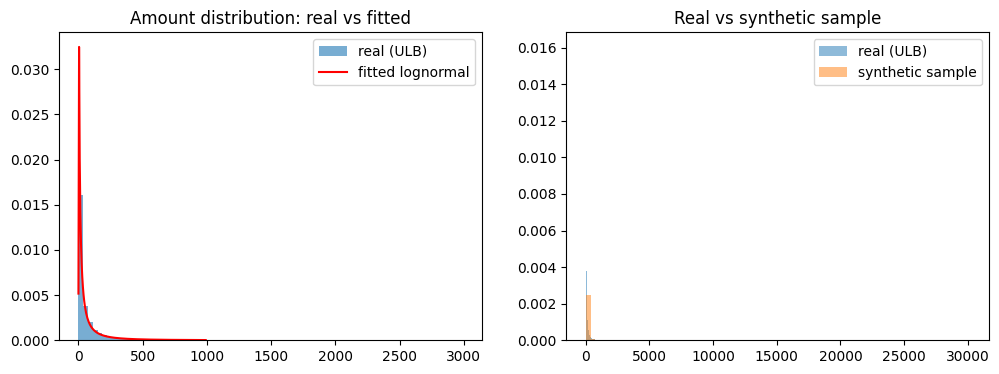

KS-test: statistic=0.0584, p-value=0.0000
(report this p-value/statistic in your slides as a rigor signal)


In [6]:
# ULB amounts are already in a usable currency-agnostic scale; IEEE-CIS TransactionAmt
# is USD. We fit on ULB (larger, cleaner amount field) and cross-check shape against IEEE-CIS.
amounts = ulb['Amount']
amounts = amounts[(amounts > 0) & (amounts < amounts.quantile(0.999))]  # drop extreme outliers before fitting

shape, loc, scale = stats.lognorm.fit(amounts, floc=0)
print(f"Fitted lognorm: shape(sigma)={shape:.4f}, loc={loc:.4f}, scale={scale:.4f}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(amounts, bins=80, density=True, alpha=0.6, label='real (ULB)')
x = np.linspace(amounts.min(), amounts.quantile(0.99), 200)
ax[0].plot(x, stats.lognorm.pdf(x, shape, loc, scale), 'r-', label='fitted lognormal')
ax[0].legend(); ax[0].set_title('Amount distribution: real vs fitted')

synthetic_sample = stats.lognorm.rvs(shape, loc, scale, size=5000, random_state=42)
ax[1].hist(amounts, bins=80, density=True, alpha=0.5, label='real (ULB)')
ax[1].hist(synthetic_sample, bins=80, density=True, alpha=0.5, label='synthetic sample')
ax[1].legend(); ax[1].set_title('Real vs synthetic sample')
plt.show()

ks_stat, ks_pval = stats.ks_2samp(amounts, synthetic_sample)
print(f"KS-test: statistic={ks_stat:.4f}, p-value={ks_pval:.4f}")
print("(report this p-value/statistic in your slides as a rigor signal)")

## Step 3 — Fit inter-transaction timing (from IEEE-CIS TransactionDT deltas)

In [7]:
ieee_sorted = ieee.sort_values('TransactionDT')
deltas = ieee_sorted['TransactionDT'].diff().dropna()
deltas = deltas[deltas > 0]

exp_scale = deltas.mean()
print(f"Fitted exponential inter-arrival: scale (mean seconds)={exp_scale:.1f}")

Fitted exponential inter-arrival: scale (mean seconds)=27.4


## Step 4 — Diurnal hour-of-day weights

Diurnal weights (24 values): [0.064, 0.0555, 0.0453, 0.0352, 0.0251, 0.0164, 0.0102, 0.0063, 0.0044, 0.0042, 0.0061, 0.0116, 0.0211, 0.0344, 0.048, 0.0573, 0.0655, 0.069, 0.0705, 0.0713, 0.0708, 0.0705, 0.0697, 0.0676]


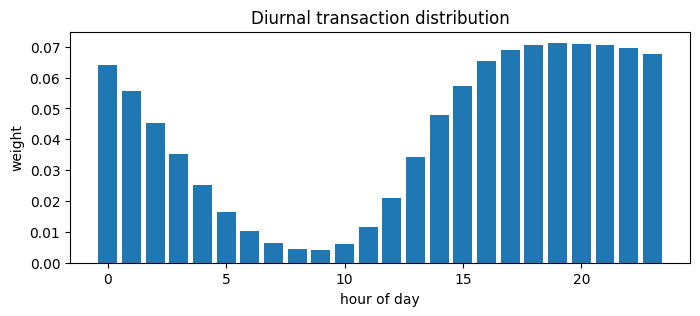

In [8]:
# TransactionDT is seconds-from-reference, not wall clock - approximate hour-of-day via modulo.
hours = (ieee_sorted['TransactionDT'] // 3600) % 24
hour_counts = hours.value_counts().sort_index()
hour_weights = (hour_counts / hour_counts.sum()).round(4).tolist()
print("Diurnal weights (24 values):", hour_weights)

plt.figure(figsize=(8, 3))
plt.bar(range(24), hour_weights)
plt.xlabel('hour of day'); plt.ylabel('weight'); plt.title('Diurnal transaction distribution')
plt.show()

## Step 5 — MCC / product-category frequency (IEEE-CIS ProductCD as proxy)

In [9]:
mcc_freq = (ieee['ProductCD'].value_counts(normalize=True)).round(4).to_dict()
print("ProductCD frequency (use as a rough MCC-frequency proxy):", mcc_freq)
# Map these proportions onto real MCC codes by hand in the yaml below - ProductCD
# categories don't map 1:1 to MCCs, so this is a *shape* reference, not a literal mapping.

ProductCD frequency (use as a rough MCC-frequency proxy): {'W': 0.7445, 'C': 0.116, 'R': 0.0638, 'H': 0.0559, 'S': 0.0197}


## Step 6 — Write everything to `config/distribution_params.yaml`

In [10]:
with open("config/distribution_params.yaml") as f:
    params = yaml.safe_load(f)

params["amount_distribution"]["fitted_from_real_data"] = True
params["amount_distribution"]["shape"] = float(shape)
params["amount_distribution"]["loc"] = float(loc)
params["amount_distribution"]["scale"] = float(scale)

params["interarrival_seconds"]["fitted_from_real_data"] = True
params["interarrival_seconds"]["scale"] = float(exp_scale)

params["diurnal_hour_weights"]["fitted_from_real_data"] = True
params["diurnal_hour_weights"]["weights"] = hour_weights

params["fraud_ratio"]["fitted_from_real_data"] = True
params["fraud_ratio"]["ieee_cis_observed"] = float(ieee['isFraud'].mean())
params["fraud_ratio"]["ulb_observed"] = float(ulb['Class'].mean())

with open("config/distribution_params.yaml", "w") as f:
    yaml.safe_dump(params, f, sort_keys=False)

print("Saved. fitted_from_real_data flags are now True for amount/timing/diurnal/fraud_ratio.")
print("NOTE: mcc_frequency and channel_mix weights are left as literature-default estimates -")
print("edit config/distribution_params.yaml by hand if you want to refine them from the ProductCD output above.")

Saved. fitted_from_real_data flags are now True for amount/timing/diurnal/fraud_ratio.
NOTE: mcc_frequency and channel_mix weights are left as literature-default estimates -
edit config/distribution_params.yaml by hand if you want to refine them from the ProductCD output above.
